# EDA of Assertions Data
## Author: Marissa Burton

### Packages Needed

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

#### Count of Non-Null Values

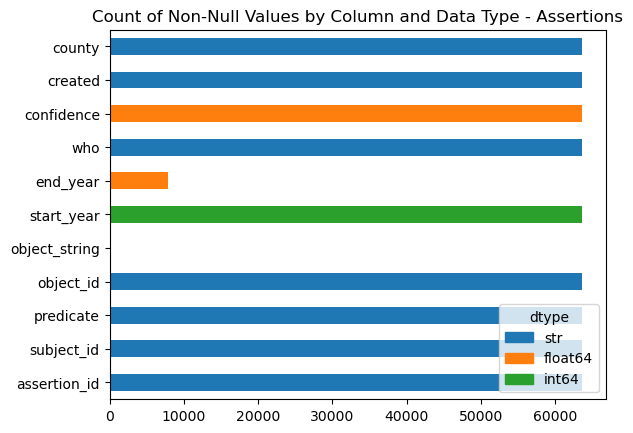

In [ ]:
assertions = pd.read_csv("data/assertions.csv") # enter file path here
info = assertions.dtypes.astype(str)
colors = {t: c for t, c in zip(info.unique(), plt.cm.tab10.colors)}

assertions.notna().sum().plot(kind='barh', color=info.map(colors))
plt.title('Count of Non-Null Values by Column and Data Type - Assertions')
plt.legend(handles=[Patch(color=c, label=t) for t, c in colors.items()], title='dtype', loc='lower right')
plt.show()

#### `mention_id` Coverage Across Assertions

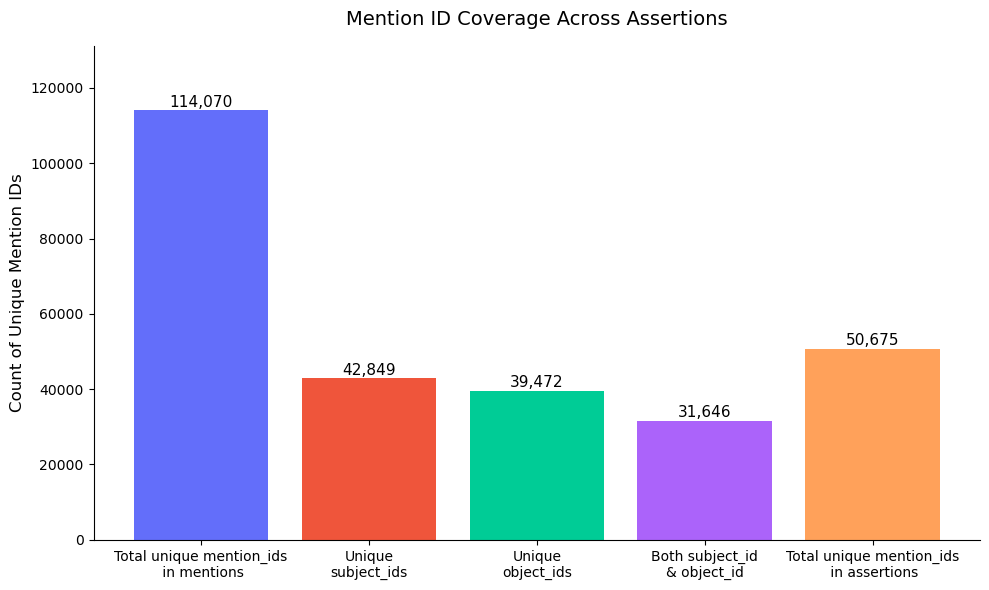

In [55]:
labels = [
    "Total unique mention_ids\n in mentions",
    "Unique\nsubject_ids",
    "Unique\nobject_ids",
    "Both subject_id\n& object_id",
    "Total unique mention_ids\n in assertions"
]

subject_ids = set(assertions['subject_id'].unique())
mention_ids = set(mentions['mention_id'].unique())
object_ids = set(assertions['object_id'].unique())
both = subject_ids & object_ids
all_mention_ids_in_assertions = subject_ids | object_ids

values = [
    len(mention_ids),
    len(subject_ids),
    len(object_ids),
    len(both),
    len(all_mention_ids_in_assertions)
]
colors = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, values, color=colors)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=11)

ax.set_title("Mention ID Coverage Across Assertions", fontsize=14, pad=15)
ax.set_ylabel("Count of Unique Mention IDs", fontsize=12)
ax.set_ylim(0, max(values) * 1.15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

#### Distribution of `subject_id` Feature

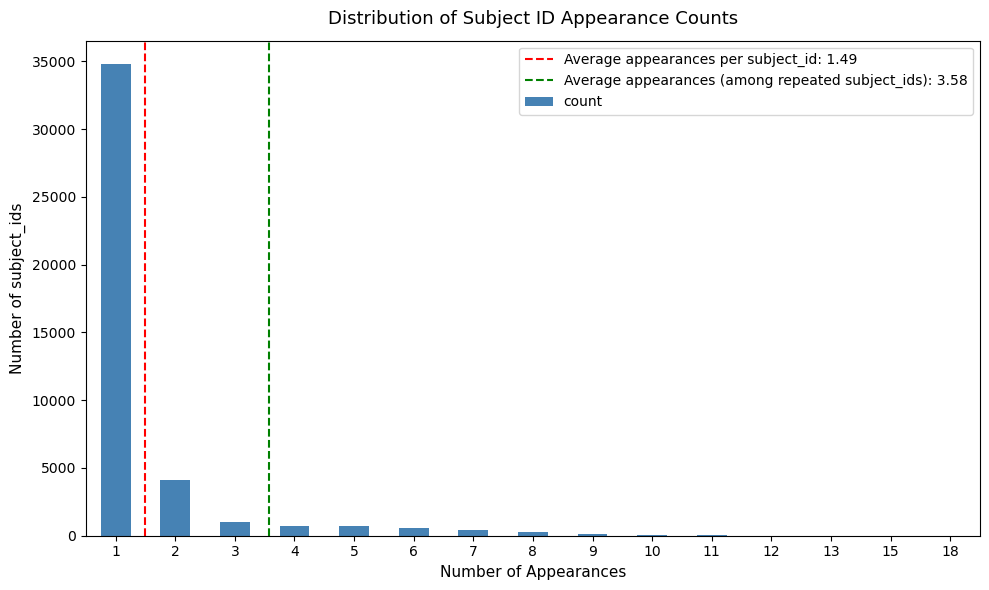

In [64]:
subject_counts = assertions['subject_id'].value_counts()
mean_appearances = subject_counts.mean()
mean_repeated = subject_counts[subject_counts > 1].mean()

fig, ax = plt.subplots(figsize=(10, 6))
subject_counts.value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')

ax.axvline(mean_appearances - 1, color='red', linestyle='--', linewidth=1.5, label=f'Average appearances per subject_id: {mean_appearances:.2f}')
ax.axvline(mean_repeated - 1, color='green', linestyle='--', linewidth=1.5, label=f'Average appearances (among repeated subject_ids): {mean_repeated:.2f}')

ax.set_title('Distribution of Subject ID Appearance Counts', fontsize=13, pad=12)
ax.set_xlabel('Number of Appearances', fontsize=11)
ax.set_ylabel('Number of subject_ids', fontsize=11)
ax.tick_params(axis='x', rotation=0)
ax.legend()
plt.tight_layout()
plt.show()

#### Distribution of `object_id` Feature

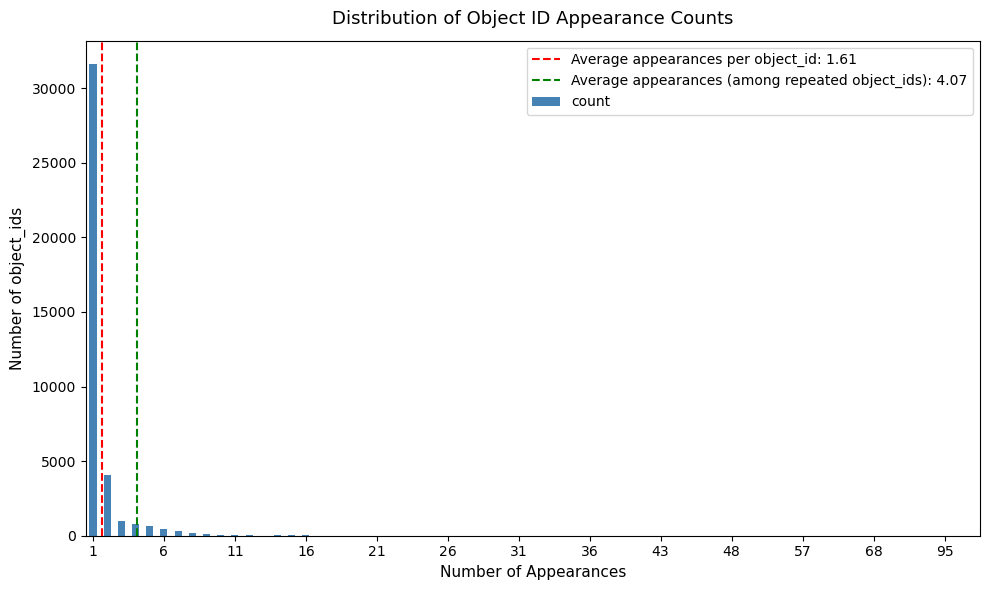

In [63]:
object_counts = assertions['object_id'].value_counts()
mean_appearances = object_counts.mean()
mean_repeated = object_counts[object_counts > 1].mean()

fig, ax = plt.subplots(figsize=(10, 6))
value_counts_sorted = object_counts.value_counts().sort_index()
value_counts_sorted.plot(kind='bar', ax=ax, color='steelblue')

ax.axvline(mean_appearances - 1, color='red', linestyle='--', linewidth=1.5, label=f'Average appearances per object_id: {mean_appearances:.2f}')
ax.axvline(mean_repeated - 1, color='green', linestyle='--', linewidth=1.5, label=f'Average appearances (among repeated object_ids): {mean_repeated:.2f}')

ax.set_title('Distribution of Object ID Appearance Counts', fontsize=13, pad=12)
ax.set_xlabel('Number of Appearances', fontsize=11)
ax.set_ylabel('Number of object_ids', fontsize=11)

# only show every 5th x-tick label
tick_step = 5
ax.set_xticks(range(0, len(value_counts_sorted), tick_step))
ax.set_xticklabels(value_counts_sorted.index[::tick_step])

ax.tick_params(axis='x', rotation=0)
ax.legend()
plt.tight_layout()
plt.show()

#### Distribution of Sources

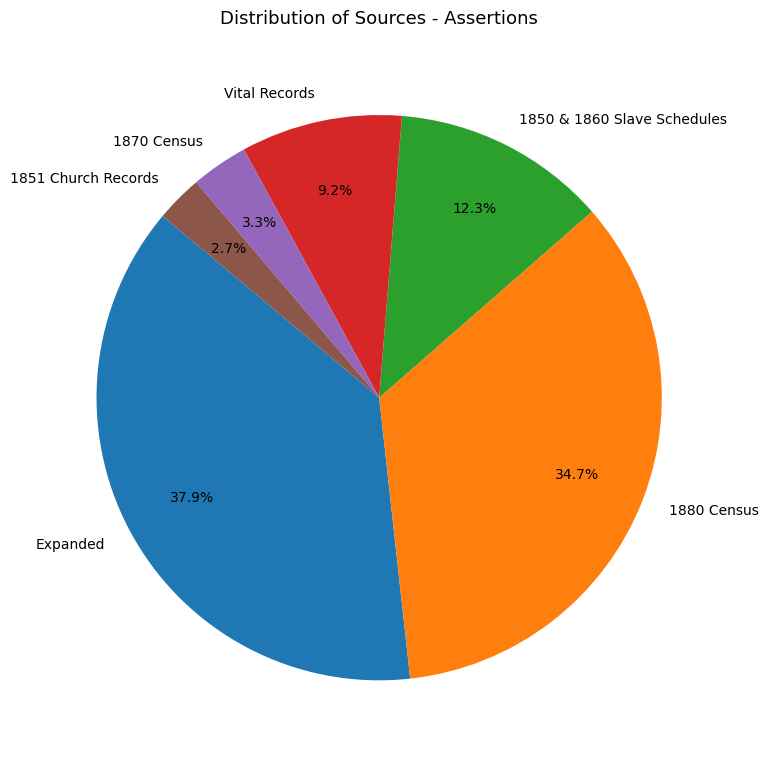

In [45]:
who_counts = assertions['who'].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    who_counts.values,
    labels=[rename_map.get(label, label) for label in who_counts.index],
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.75
)

ax.set_title("Distribution of Sources - Assertions", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

#### Assertion Count by `predicate` and Source (`who`)

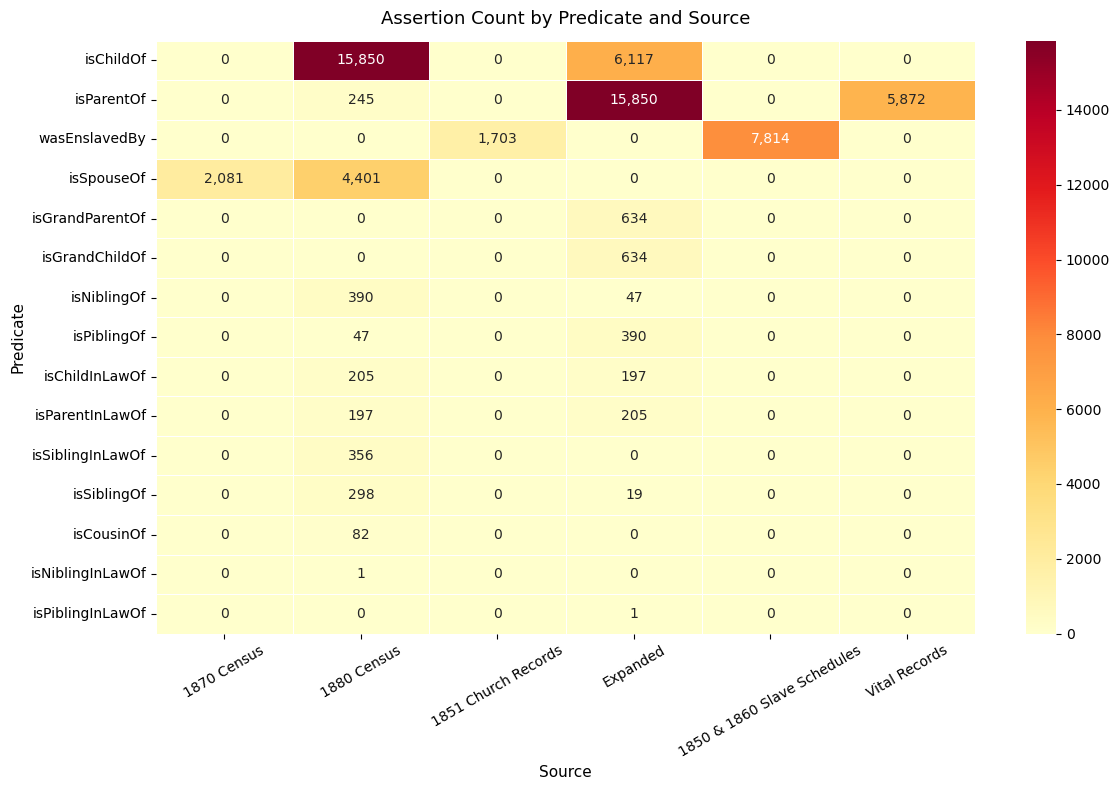

In [46]:
heatmap_data = assertions.groupby(['predicate', 'who']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.rename(columns=rename_map)

predicate_counts = assertions['predicate'].value_counts().sort_values(ascending=False)
heatmap_data = heatmap_data.loc[predicate_counts.index]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=',',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
)

ax.set_title("Assertion Count by Predicate and Source", fontsize=13, pad=12)
ax.set_xlabel("Source", fontsize=11)
ax.set_ylabel("Predicate", fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()